# Transformer & Modern-Architecture Evaluation on Fashion-MNIST (CNN vs ViT vs Hybrid vs ConvNeXt-style)

**Student Name:** _[Fill in]_
**Registration Number:** _[Fill in]_
**Section:** _[Fill in]_

**What this notebook does:** extends the earlier Attention-CNN notebook. The CNN baselines (plain CNN, CBAM-CNN) are kept as references, and three newer architectures are trained and evaluated on the identical data split, augmentation, optimizer and schedule:

| Family | Model | Idea |
|---|---|---|
| CNN (reference) | Baseline CNN, CBAM-CNN | Conv blocks, optional channel+spatial attention |
| Transformer | **ViT-Small** | Image cut into patches, pure self-attention encoder |
| CNN + Transformer | **Hybrid Conv-Transformer** | Conv stem for local features, transformer encoder for global context |
| Modern CNN | **ConvNeXt-style** | CNN redesigned with transformer-era choices (7x7 depthwise conv, LayerNorm, GELU, LayerScale) |

**Evaluation beyond accuracy:** per-class metrics, ROC-AUC, specificity, calibration (ECE, NLL), efficiency (params, train time, latency), McNemar significance tests, and an optional multi-seed study.

**Expectation, stated up front:** Transformers trained from scratch on 54k tiny 28x28 images have little inductive bias to lean on. A plain ViT is likely to land at or *below* a good CNN here; the hybrid and ConvNeXt-style models are the ones most likely to match or beat it. The notebook reports whatever the numbers show.

**Dataset access:** streamed via `keras.datasets.fashion_mnist` (no manual download).

In [1]:
import os, time, math, itertools
os.environ.setdefault("KERAS_BACKEND", "tensorflow")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
import keras
from keras import layers, models, callbacks, ops
from scipy.stats import binomtest
from sklearn.metrics import (classification_report, confusion_matrix, roc_auc_score,
                             precision_recall_fscore_support, accuracy_score, log_loss)
from sklearn.preprocessing import label_binarize
from sklearn.model_selection import train_test_split

SEED = 42
keras.utils.set_random_seed(SEED)

# ---- Run configuration ----
QUICK_RUN      = False   # True = tiny subset + 1-2 epochs, only to check the notebook runs end-to-end
RUN_SEED_STUDY = False   # True = retrain every model with several seeds (slow, ~3x training time)
SEED_RUNS      = 3
BATCH_SIZE     = 128
EPOCHS         = 2 if QUICK_RUN else 30
TUNE_EPOCHS    = 1 if QUICK_RUN else 6
LEARNING_RATE  = 1e-3
WEIGHT_DECAY   = 0.05

print("TensorFlow:", tf.__version__, "| Keras:", keras.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))

TensorFlow: 2.21.0 | Keras: 3.13.2
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 2. Dataset Loading

In [2]:
(x_train_full, y_train_full), (x_test, y_test) = keras.datasets.fashion_mnist.load_data()

class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

print("Full training set:", x_train_full.shape, y_train_full.shape)
print("Test set:", x_test.shape, y_test.shape)

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Full training set: (60000, 28, 28) (60000,)
Test set: (10000, 28, 28) (10000,)


## 3. Dataset Analysis

      Class  Count
T-shirt/top   6000
    Trouser   6000
   Pullover   6000
      Dress   6000
       Coat   6000
     Sandal   6000
      Shirt   6000
    Sneaker   6000
        Bag   6000
 Ankle boot   6000


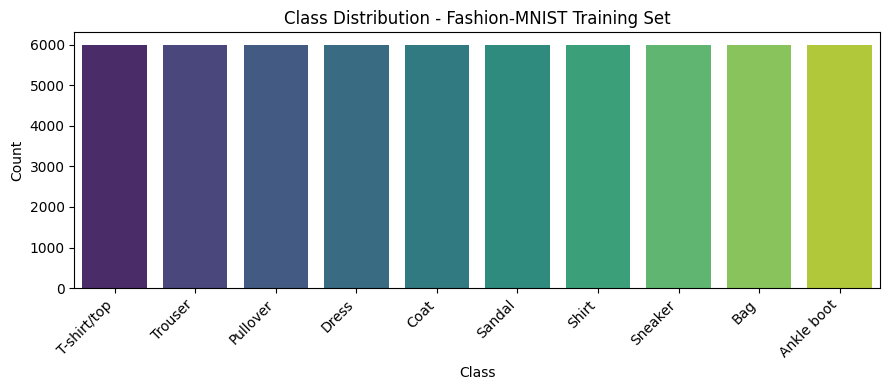

In [3]:
# 3.1 Class distribution
unique, counts = np.unique(y_train_full, return_counts=True)
dist_df = pd.DataFrame({'Class': [class_names[i] for i in unique], 'Count': counts})
print(dist_df.to_string(index=False))

plt.figure(figsize=(9, 4))
sns.barplot(data=dist_df, x='Class', y='Count', hue='Class', legend=False, palette='viridis')
plt.xticks(rotation=45, ha='right')
plt.title('Class Distribution - Fashion-MNIST Training Set')
plt.tight_layout()
plt.show()

In [4]:
# 3.2 Class imbalance analysis
counts_arr = dist_df['Count'].values
imbalance_ratio = counts_arr.max() / counts_arr.min()
print(f"Min class count: {counts_arr.min()} | Max class count: {counts_arr.max()}")
print(f"Imbalance ratio (max/min): {imbalance_ratio:.3f}")
print(f"Std dev across class counts: {counts_arr.std():.2f}")
if imbalance_ratio < 1.5:
    print("Conclusion: classes are BALANCED (ratio < 1.5). No resampling or class weighting needed.")
else:
    print("Conclusion: imbalance detected. Consider class weighting, oversampling, or focal loss.")

Min class count: 6000 | Max class count: 6000
Imbalance ratio (max/min): 1.000
Std dev across class counts: 0.00
Conclusion: classes are BALANCED (ratio < 1.5). No resampling or class weighting needed.


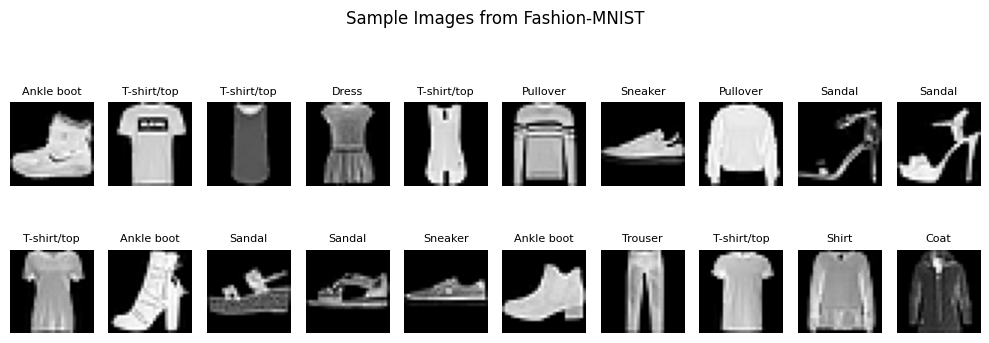

In [5]:
# 3.3 Sample images
plt.figure(figsize=(10, 4))
for i in range(20):
    plt.subplot(2, 10, i + 1)
    plt.imshow(x_train_full[i], cmap='gray')
    plt.title(class_names[y_train_full[i]], fontsize=8)
    plt.axis('off')
plt.suptitle('Sample Images from Fashion-MNIST')
plt.tight_layout()
plt.show()

## 4. Preprocessing, Split and Augmentation

In [6]:
x_train_full = np.expand_dims(x_train_full.astype('float32') / 255.0, -1)   # (N, 28, 28, 1)
x_test       = np.expand_dims(x_test.astype('float32') / 255.0, -1)

x_train, x_val, y_train, y_val = train_test_split(
    x_train_full, y_train_full, test_size=0.10, random_state=SEED, stratify=y_train_full)

if QUICK_RUN:   # tiny subsets just to verify the pipeline
    x_train, y_train = x_train[:3000], y_train[:3000]
    x_val, y_val = x_val[:600], y_val[:600]
    x_test, y_test = x_test[:1000], y_test[:1000]

print(pd.DataFrame({
    'Split': ['Train', 'Validation', 'Test'],
    'Samples': [len(x_train), len(x_val), len(x_test)],
}).to_string(index=False))

     Split  Samples
     Train    54000
Validation     6000
      Test    10000


In [7]:
preprocessing_df = pd.DataFrame([
    {'Step': 'Pixel normalization', 'Parameter': 'x / 255.0',
     'Effect': 'Scales intensity to [0, 1]'},
    {'Step': 'Channel expansion', 'Parameter': 'expand_dims(axis=-1)',
     'Effect': '(28, 28) -> (28, 28, 1) for Conv2D / patch embedding'},
    {'Step': 'Train/Val split', 'Parameter': 'test_size=0.10, stratified, seed=42',
     'Effect': 'Class proportions preserved'},
    {'Step': 'Augmentation (all models, train only)', 'Parameter': 'RandomFlip(horizontal), RandomTranslation(10%)',
     'Effect': 'Applied identically inside every model so the comparison stays fair; '
               'matters most for transformers, which overfit small images easily'},
    {'Step': 'Labels', 'Parameter': 'Integer 0-9',
     'Effect': 'sparse_categorical_crossentropy'},
])
preprocessing_df

,Step,Parameter,Effect
0,Pixel normalization,x / 255.0,"Scales intensity to [0, 1]"
1,Channel expansion,expand_dims(axis=-1),"(28, 28) -> (28, 28, 1) for Conv2D / patch emb..."
2,Train/Val split,"test_size=0.10, stratified, seed=42",Class proportions preserved
3,"Augmentation (all models, train only)","RandomFlip(horizontal), RandomTranslation(10%)",Applied identically inside every model so the ...
4,Labels,Integer 0-9,sparse_categorical_crossentropy


## 5. Model Architectures

All five models share: the same input pipeline, the same in-model augmentation, a 10-way softmax head, and the same optimizer/schedule (Section 7). Only the backbone differs.

* **Baseline CNN / CBAM-CNN**: carried over from the earlier notebook (3 conv blocks, global average pooling, dense head). Spatial attention uses small custom layers instead of `Lambda`, which is safer across Keras versions.
* **ViT-Small**: 28x28 image -> non-overlapping patches (Conv2D with stride = patch size) -> learned positional embedding -> N pre-norm transformer encoder blocks (multi-head self-attention + GELU MLP) -> mean-pool over tokens -> classifier. No class token (mean pooling is simpler and performs comparably on small images).
* **Hybrid Conv-Transformer**: two conv blocks reduce 28x28 to 14x14 feature maps, a third reduces to 7x7 with `dim` channels; those 49 feature vectors become tokens for a shallow transformer encoder. Convolutions supply locality, attention supplies global context.
* **ConvNeXt-style**: a CNN modernised with transformer-era design choices: patchify stem, 7x7 depthwise conv, LayerNorm, inverted-bottleneck MLP with GELU, LayerScale, residual connections. It is "newer technology" without any attention.

In [8]:
# ---------- Shared pieces ----------
def augmentation():
    return keras.Sequential([
        layers.RandomFlip("horizontal"),
        layers.RandomTranslation(0.1, 0.1, fill_mode="constant"),
    ], name="augment")


def conv_block(x, filters):
    x = layers.Conv2D(filters, 3, padding='same', activation='relu')(x)
    return layers.BatchNormalization()(x)


# ---------- CBAM pieces (reference CNNs) ----------
class ChannelStats(layers.Layer):
    """Stacks per-pixel mean and max across channels -> (H, W, 2)."""
    def call(self, x):
        return ops.concatenate([ops.mean(x, axis=-1, keepdims=True),
                                ops.max(x, axis=-1, keepdims=True)], axis=-1)
    def compute_output_shape(self, s):
        return (*s[:-1], 2)


def channel_attention(x, ratio=8):
    ch = x.shape[-1]
    d1 = layers.Dense(max(ch // ratio, 4), activation='relu')
    d2 = layers.Dense(ch)
    avg = d2(d1(layers.GlobalAveragePooling2D()(x)))
    mx  = d2(d1(layers.GlobalMaxPooling2D()(x)))
    att = layers.Activation('sigmoid')(layers.Add()([avg, mx]))
    att = layers.Reshape((1, 1, ch))(att)
    return layers.Multiply()([x, att])


def spatial_attention(x):
    att = layers.Conv2D(1, 7, padding='same', activation='sigmoid')(ChannelStats()(x))
    return layers.Multiply()([x, att])


def cbam_block(x, ratio=8):
    return spatial_attention(channel_attention(x, ratio))


def build_cnn(attention=None, dropout=0.3, name='CNN'):
    inputs = layers.Input((28, 28, 1))
    x = augmentation()(inputs)
    for i, f in enumerate([32, 64, 128]):
        x = conv_block(x, f)
        if attention == 'cbam':
            x = cbam_block(x)
        if i < 2:
            x = layers.MaxPooling2D()(x)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(dropout)(x)
    return models.Model(inputs, layers.Dense(10, activation='softmax')(x), name=name)


# ---------- Transformer pieces ----------
class AddPositionEmbedding(layers.Layer):
    """Learned positional embedding added to a (B, N, D) token tensor."""
    def build(self, input_shape):
        self.pos = self.add_weight(shape=(1, input_shape[1], input_shape[2]),
                                   initializer=keras.initializers.TruncatedNormal(stddev=0.02),
                                   name='pos_embedding')
    def call(self, x):
        return x + self.pos
    def compute_output_shape(self, s):
        return s


class TransformerBlock(layers.Layer):
    """Pre-norm encoder block: x + MHSA(LN(x)); x + MLP(LN(x))."""
    def __init__(self, dim, heads, mlp_ratio=2.0, dropout=0.1, **kw):
        super().__init__(**kw)
        self.norm1 = layers.LayerNormalization(epsilon=1e-6)
        self.attn  = layers.MultiHeadAttention(num_heads=heads, key_dim=dim // heads, dropout=dropout)
        self.norm2 = layers.LayerNormalization(epsilon=1e-6)
        self.mlp   = keras.Sequential([
            layers.Dense(int(dim * mlp_ratio), activation='gelu'), layers.Dropout(dropout),
            layers.Dense(dim), layers.Dropout(dropout)])

    def call(self, x, training=None, return_attention=False):
        h = self.norm1(x)
        if return_attention:
            a, scores = self.attn(h, h, return_attention_scores=True, training=training)
        else:
            a = self.attn(h, h, training=training)
        x = x + a
        x = x + self.mlp(self.norm2(x), training=training)
        return (x, scores) if return_attention else x

    def compute_output_shape(self, s):
        return s


def transformer_head(x, depth, dim, heads, mlp_ratio, dropout):
    x = AddPositionEmbedding(name='pos_embed')(x)
    x = layers.Dropout(dropout)(x)
    for i in range(depth):
        x = TransformerBlock(dim, heads, mlp_ratio, dropout, name=f'block_{i}')(x)
    x = layers.LayerNormalization(epsilon=1e-6)(x)
    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dropout(dropout)(x)
    return layers.Dense(10, activation='softmax')(x)


def build_vit(patch_size=4, dim=64, depth=6, heads=4, mlp_ratio=2.0, dropout=0.1, name='ViT'):
    inputs = layers.Input((28, 28, 1))
    x = augmentation()(inputs)
    x = layers.Conv2D(dim, patch_size, strides=patch_size, name='patch_embed')(x)   # patchify + linear projection
    x = layers.Reshape(((28 // patch_size) ** 2, dim))(x)
    return models.Model(inputs, transformer_head(x, depth, dim, heads, mlp_ratio, dropout), name=name)


def build_hybrid(dim=96, depth=3, heads=4, mlp_ratio=2.0, dropout=0.1, name='Hybrid'):
    inputs = layers.Input((28, 28, 1))
    x = augmentation()(inputs)
    x = conv_block(x, 32)
    x = conv_block(x, 64)
    x = layers.MaxPooling2D()(x)                      # 14x14
    x = conv_block(x, dim)
    x = layers.MaxPooling2D()(x)                      # 7x7 -> 49 tokens
    x = layers.Reshape((49, dim))(x)
    return models.Model(inputs, transformer_head(x, depth, dim, heads, mlp_ratio, dropout), name=name)


# ---------- ConvNeXt-style ----------
class LayerScale(layers.Layer):
    def __init__(self, init_value=1e-6, **kw):
        super().__init__(**kw)
        self.init_value = init_value
    def build(self, input_shape):
        self.gamma = self.add_weight(shape=(input_shape[-1],),
                                     initializer=keras.initializers.Constant(self.init_value), name='gamma')
    def call(self, x):
        return x * self.gamma
    def compute_output_shape(self, s):
        return s


def convnext_block(x, dim, dropout):
    shortcut = x
    x = layers.DepthwiseConv2D(7, padding='same')(x)
    x = layers.LayerNormalization(epsilon=1e-6)(x)
    x = layers.Dense(4 * dim, activation='gelu')(x)
    x = layers.Dense(dim)(x)
    x = LayerScale()(x)
    x = layers.Dropout(dropout)(x)
    return layers.Add()([shortcut, x])


def build_convnext(dims=(48, 96), depths=(2, 2), dropout=0.1, name='ConvNeXt'):
    inputs = layers.Input((28, 28, 1))
    x = augmentation()(inputs)
    x = layers.Conv2D(dims[0], 2, strides=2)(x)                    # patchify stem -> 14x14
    x = layers.LayerNormalization(epsilon=1e-6)(x)
    for _ in range(depths[0]):
        x = convnext_block(x, dims[0], dropout)
    x = layers.LayerNormalization(epsilon=1e-6)(x)
    x = layers.Conv2D(dims[1], 2, strides=2)(x)                    # downsample -> 7x7
    for _ in range(depths[1]):
        x = convnext_block(x, dims[1], dropout)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.LayerNormalization(epsilon=1e-6)(x)
    x = layers.Dropout(dropout)(x)
    return models.Model(inputs, layers.Dense(10, activation='softmax')(x), name=name)

In [9]:
from functools import partial

# Registry: model name -> (builder, family, hyperparameter grid searched in Section 6)
REGISTRY = {
    'Baseline CNN':          dict(builder=partial(build_cnn, attention=None),   family='CNN',
                                  grid={'dropout': [0.1, 0.3]}),
    'CBAM-CNN':              dict(builder=partial(build_cnn, attention='cbam'), family='CNN',
                                  grid={'dropout': [0.1, 0.3]}),
    'ConvNeXt-style':        dict(builder=build_convnext,                       family='Modern CNN',
                                  grid={'dropout': [0.1, 0.3]}),
    'ViT-Small':             dict(builder=build_vit,                            family='Transformer',
                                  grid={'dropout': [0.1, 0.3], 'patch_size': [4, 7]}),
    'Hybrid Conv-Transformer': dict(builder=build_hybrid,                       family='CNN+Transformer',
                                  grid={'dropout': [0.1, 0.3]}),
}

# Parameter-count overview with default hyperparameters
overview = []
for n, cfg in REGISTRY.items():
    m = cfg['builder'](name=n.replace(' ', '_'))
    overview.append({'Model': n, 'Family': cfg['family'], 'Parameters': m.count_params()})
    del m
pd.DataFrame(overview)

,Model,Family,Parameters
0,Baseline CNN,CNN,111370
1,CBAM-CNN,CNN,117295
2,ConvNeXt-style,Modern CNN,221146
3,ViT-Small,Transformer,205834
4,Hybrid Conv-Transformer,CNN+Transformer,305194


## 6. Hyperparameter Tuning (parameters considered, values tested, final selection)

Each model family gets its own short sweep (`TUNE_EPOCHS` epochs, no early stopping, fixed seed) over dropout; ViT additionally searches patch size (4 -> 49 tokens, 7 -> 16 tokens). Selection is by best validation accuracy, never by test accuracy. The same optimizer (AdamW, 5% warm-up then cosine decay, grad-clip 1.0) is used for all models in tuning and final training.

Caveat: a 6-epoch sweep with one seed is a coarse filter. Differences of a few tenths of a percent between configurations are noise.

In [10]:
def make_optimizer(epochs, n_train):
    steps = math.ceil(n_train / BATCH_SIZE) * epochs
    warm = max(1, int(0.05 * steps))
    sched = keras.optimizers.schedules.CosineDecay(
        0.0, decay_steps=max(1, steps - warm), alpha=0.01,
        warmup_target=LEARNING_RATE, warmup_steps=warm)
    return keras.optimizers.AdamW(learning_rate=sched, weight_decay=WEIGHT_DECAY, clipnorm=1.0)


def compile_and_train(model, epochs, patience=6, verbose=0):
    model.compile(optimizer=make_optimizer(epochs, len(x_train)),
                  loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    cbs = [callbacks.EarlyStopping(monitor='val_loss', patience=patience, restore_best_weights=True)] if patience else []
    t0 = time.time()
    hist = model.fit(x_train, y_train, validation_data=(x_val, y_val), epochs=epochs,
                     batch_size=BATCH_SIZE, callbacks=cbs, verbose=verbose)
    return hist, time.time() - t0

In [11]:
tuning_rows, best_cfg = [], {}

for name, cfg in REGISTRY.items():
    keys = list(cfg['grid'])
    best_acc, best_hp = -1.0, None
    for vals in itertools.product(*cfg['grid'].values()):
        hp = dict(zip(keys, vals))
        keras.utils.set_random_seed(SEED)
        m = cfg['builder'](name='tune', **hp)
        h, _ = compile_and_train(m, TUNE_EPOCHS, patience=None)
        acc = max(h.history['val_accuracy'])
        tuning_rows.append({'Model': name, 'Hyperparameters': str(hp), 'Best Val Acc': round(acc, 4)})
        print(f"{name:26s} {str(hp):38s} val_acc={acc:.4f}")
        if acc > best_acc:
            best_acc, best_hp = acc, hp
        del m
        keras.backend.clear_session()
    best_cfg[name] = best_hp

tuning_df = pd.DataFrame(tuning_rows)
print("\nSelected configurations (highest validation accuracy within each family):")
for k, v in best_cfg.items():
    print(f"  {k}: {v}")
tuning_df

Baseline CNN               {'dropout': 0.1}                       val_acc=0.9150
Baseline CNN               {'dropout': 0.3}                       val_acc=0.9127
CBAM-CNN                   {'dropout': 0.1}                       val_acc=0.9135
CBAM-CNN                   {'dropout': 0.3}                       val_acc=0.9128
ConvNeXt-style             {'dropout': 0.1}                       val_acc=0.8413
ConvNeXt-style             {'dropout': 0.3}                       val_acc=0.8363
ViT-Small                  {'dropout': 0.1, 'patch_size': 4}      val_acc=0.8182
ViT-Small                  {'dropout': 0.1, 'patch_size': 7}      val_acc=0.8028
ViT-Small                  {'dropout': 0.3, 'patch_size': 4}      val_acc=0.7758
ViT-Small                  {'dropout': 0.3, 'patch_size': 7}      val_acc=0.7570
Hybrid Conv-Transformer    {'dropout': 0.1}                       val_acc=0.9177
Hybrid Conv-Transformer    {'dropout': 0.3}                       val_acc=0.9107

Selected configurations (hi

,Model,Hyperparameters,Best Val Acc
0,Baseline CNN,{'dropout': 0.1},0.9150
1,Baseline CNN,{'dropout': 0.3},0.9127
2,CBAM-CNN,{'dropout': 0.1},0.9135
3,CBAM-CNN,{'dropout': 0.3},0.9128
4,ConvNeXt-style,{'dropout': 0.1},0.8413
5,ConvNeXt-style,{'dropout': 0.3},0.8363
6,ViT-Small,"{'dropout': 0.1, 'patch_size': 4}",0.8182
7,ViT-Small,"{'dropout': 0.1, 'patch_size': 7}",0.8028
8,ViT-Small,"{'dropout': 0.3, 'patch_size': 4}",0.7758
9,ViT-Small,"{'dropout': 0.3, 'patch_size': 7}",0.7570


## 7. Final Training (tuned hyperparameters, full epoch budget)

Cosine schedule over `EPOCHS`; early stopping on validation loss (patience 6) restores the best weights. The loop skips models already trained, so re-running the cell after a Colab disconnect only trains what is missing.

In [12]:
trained   = globals().get('trained', {})
histories = globals().get('histories', {})
train_times = globals().get('train_times', {})

for name, cfg in REGISTRY.items():
    if name in trained:
        continue
    print(f"\n===== Training {name} with {best_cfg[name]} =====")
    keras.utils.set_random_seed(SEED)
    m = cfg['builder'](name=name.replace(' ', '_'), **best_cfg[name])
    h, t = compile_and_train(m, EPOCHS, patience=6, verbose=2)
    trained[name], histories[name], train_times[name] = m, h, t
    print(f"{name}: {len(h.history['loss'])} epochs, {t:.1f}s, {m.count_params():,} params")


===== Training Baseline CNN with {'dropout': 0.1} =====
Epoch 1/30
422/422 - 10s - 25ms/step - accuracy: 0.6561 - loss: 1.0194 - val_accuracy: 0.2017 - val_loss: 2.6962
Epoch 2/30
422/422 - 7s - 17ms/step - accuracy: 0.8322 - loss: 0.4568 - val_accuracy: 0.8123 - val_loss: 0.5132
Epoch 3/30
422/422 - 7s - 16ms/step - accuracy: 0.8683 - loss: 0.3591 - val_accuracy: 0.8060 - val_loss: 0.5285
Epoch 4/30
422/422 - 7s - 16ms/step - accuracy: 0.8837 - loss: 0.3183 - val_accuracy: 0.8943 - val_loss: 0.2889
Epoch 5/30
422/422 - 7s - 17ms/step - accuracy: 0.8910 - loss: 0.2958 - val_accuracy: 0.8947 - val_loss: 0.2850
Epoch 6/30
422/422 - 6s - 15ms/step - accuracy: 0.8980 - loss: 0.2793 - val_accuracy: 0.8993 - val_loss: 0.2680
Epoch 7/30
422/422 - 7s - 17ms/step - accuracy: 0.9019 - loss: 0.2675 - val_accuracy: 0.8963 - val_loss: 0.2990
Epoch 8/30
422/422 - 6s - 15ms/step - accuracy: 0.9044 - loss: 0.2596 - val_accuracy: 0.8853 - val_loss: 0.3120
Epoch 9/30
422/422 - 7s - 16ms/step - accuracy

## 8. Training Curves

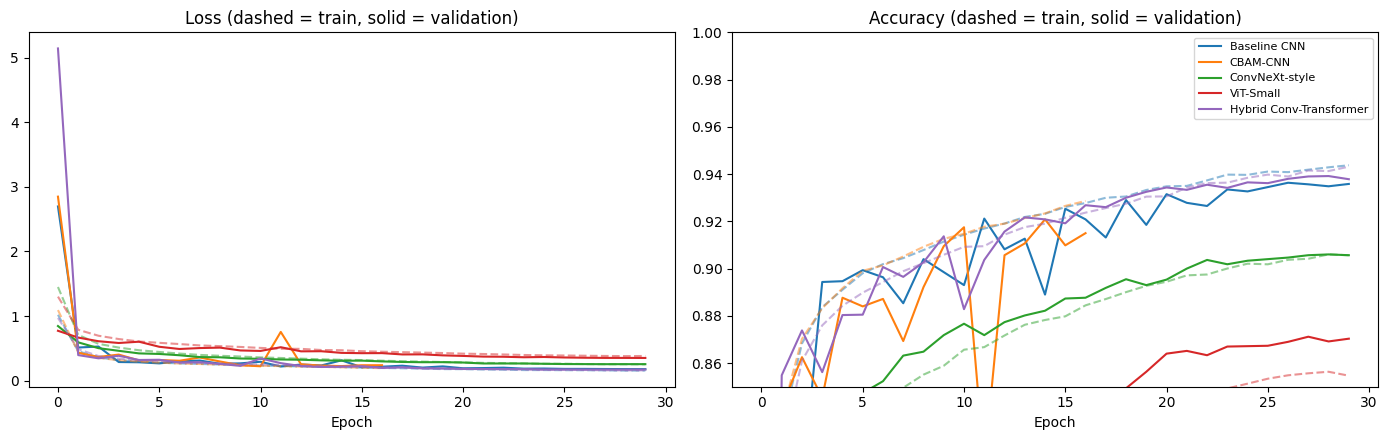

In [13]:
palette = dict(zip(REGISTRY.keys(), sns.color_palette('tab10', len(REGISTRY))))

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
for name, h in histories.items():
    c = palette[name]
    axes[0].plot(h.history['loss'], '--', color=c, alpha=0.5)
    axes[0].plot(h.history['val_loss'], color=c, label=name)
    axes[1].plot(h.history['accuracy'], '--', color=c, alpha=0.5)
    axes[1].plot(h.history['val_accuracy'], color=c, label=name)
axes[0].set_title('Loss (dashed = train, solid = validation)'); axes[0].set_xlabel('Epoch')
axes[1].set_title('Accuracy (dashed = train, solid = validation)'); axes[1].set_xlabel('Epoch')
axes[1].set_ylim(0.85, 1.0)
axes[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

## 9. Convergence Analysis

Epochs actually run, epoch of best validation loss, and the train-validation accuracy gap. Note: all models train with augmentation active, so training accuracy is measured on augmented images and can sit *below* validation accuracy; a negative gap is not a bug.

In [14]:
rows = []
for name, h in histories.items():
    hh = h.history
    rows.append({
        'Model': name,
        'Epochs Run': len(hh['loss']),
        'Best Epoch (val loss)': int(np.argmin(hh['val_loss'])) + 1,
        'Final Train Acc': round(hh['accuracy'][-1], 4),
        'Final Val Acc': round(hh['val_accuracy'][-1], 4),
        'Train-Val Gap': round(hh['accuracy'][-1] - hh['val_accuracy'][-1], 4),
    })
convergence_df = pd.DataFrame(rows)
print(convergence_df.to_string(index=False))
print()
for _, r in convergence_df.iterrows():
    stop = "stopped early" if r['Epochs Run'] < EPOCHS else "ran full budget"
    flag = "possible overfitting" if r['Train-Val Gap'] > 0.05 else "no significant overfitting"
    print(f"{r['Model']}: {stop} ({r['Epochs Run']} epochs), gap={r['Train-Val Gap']:+.3f} -> {flag}")
convergence_df

                  Model  Epochs Run  Best Epoch (val loss)  Final Train Acc  Final Val Acc  Train-Val Gap
           Baseline CNN          30                     30           0.9437         0.9358         0.0079
               CBAM-CNN          17                     11           0.9286         0.9150         0.0136
         ConvNeXt-style          30                     28           0.9056         0.9057        -0.0000
              ViT-Small          30                     30           0.8547         0.8703        -0.0157
Hybrid Conv-Transformer          30                     27           0.9431         0.9378         0.0053

Baseline CNN: ran full budget (30 epochs), gap=+0.008 -> no significant overfitting
CBAM-CNN: stopped early (17 epochs), gap=+0.014 -> no significant overfitting
ConvNeXt-style: ran full budget (30 epochs), gap=-0.000 -> no significant overfitting
ViT-Small: ran full budget (30 epochs), gap=-0.016 -> no significant overfitting
Hybrid Conv-Transformer: ran full 

,Model,Epochs Run,Best Epoch (val loss),Final Train Acc,Final Val Acc,Train-Val Gap
0,Baseline CNN,30,30,0.9437,0.9358,0.0079
1,CBAM-CNN,17,11,0.9286,0.9150,0.0136
2,ConvNeXt-style,30,28,0.9056,0.9057,-0.0000
3,ViT-Small,30,30,0.8547,0.8703,-0.0157
4,Hybrid Conv-Transformer,30,27,0.9431,0.9378,0.0053


## 10. Evaluation on the Held-Out Test Set

Accuracy, macro/weighted precision-recall-F1, macro specificity, macro ROC-AUC (one-vs-rest), per-class tables, and confusion matrices for every model.

In [15]:
def specificity_per_class(cm):
    total, out = cm.sum(), []
    for i in range(cm.shape[0]):
        tp = cm[i, i]; fn = cm[i, :].sum() - tp; fp = cm[:, i].sum() - tp
        tn = total - tp - fn - fp
        out.append(tn / (tn + fp) if (tn + fp) else 0.0)
    return np.array(out)


def expected_calibration_error(y_true, y_prob, n_bins=15):
    conf, pred = y_prob.max(1), y_prob.argmax(1)
    correct = (pred == y_true).astype(float)
    edges = np.linspace(0, 1, n_bins + 1)
    ece = 0.0
    for lo, hi in zip(edges[:-1], edges[1:]):
        m = (conf > lo) & (conf <= hi)
        if m.any():
            ece += m.mean() * abs(correct[m].mean() - conf[m].mean())
    return ece


def evaluate_model(model, name):
    y_prob = model.predict(x_test, batch_size=512, verbose=0)
    y_pred = y_prob.argmax(1)
    p, r, f1, _ = precision_recall_fscore_support(y_test, y_pred, average='macro', zero_division=0)
    pw, rw, f1w, _ = precision_recall_fscore_support(y_test, y_pred, average='weighted', zero_division=0)
    y_bin = label_binarize(y_test, classes=list(range(10)))
    cm = confusion_matrix(y_test, y_pred, labels=list(range(10)))
    spec = specificity_per_class(cm)
    rep = classification_report(y_test, y_pred, labels=list(range(10)), target_names=class_names,
                                output_dict=True, zero_division=0)
    per_class = pd.DataFrame({
        'Class': class_names,
        'Precision': [rep[c]['precision'] for c in class_names],
        'Recall': [rep[c]['recall'] for c in class_names],
        'F1': [rep[c]['f1-score'] for c in class_names],
        'Specificity': spec,
        'ROC-AUC': roc_auc_score(y_bin, y_prob, average=None),
    })
    return dict(name=name, y_prob=y_prob, y_pred=y_pred, cm=cm, per_class=per_class,
                accuracy=accuracy_score(y_test, y_pred),
                precision_macro=p, recall_macro=r, f1_macro=f1,
                precision_weighted=pw, recall_weighted=rw, f1_weighted=f1w,
                specificity_macro=spec.mean(),
                roc_auc_macro=roc_auc_score(y_bin, y_prob, average='macro'),
                ece=expected_calibration_error(y_test, y_prob),
                nll=log_loss(y_test, y_prob, labels=list(range(10))))


results = {name: evaluate_model(m, name) for name, m in trained.items()}

summary_df = pd.DataFrame([{
    'Model': n, 'Family': REGISTRY[n]['family'],
    'Accuracy': r['accuracy'], 'Precision (macro)': r['precision_macro'],
    'Recall (macro)': r['recall_macro'], 'F1 (macro)': r['f1_macro'],
    'Specificity (macro)': r['specificity_macro'], 'ROC-AUC (macro)': r['roc_auc_macro'],
} for n, r in results.items()]).sort_values('Accuracy', ascending=False).reset_index(drop=True)
summary_df.round(4)

,Model,Family,Accuracy,Precision (macro),Recall (macro),F1 (macro),Specificity (macro),ROC-AUC (macro)
0,Baseline CNN,CNN,0.9291,0.9292,0.9291,0.9290,0.9921,0.9962
1,Hybrid Conv-Transformer,CNN+Transformer,0.9272,0.9268,0.9272,0.9269,0.9919,0.9961
2,CBAM-CNN,CNN,0.9097,0.9093,0.9097,0.9092,0.9900,0.9942
3,ConvNeXt-style,Modern CNN,0.8947,0.8949,0.8947,0.8946,0.9883,0.9924
4,ViT-Small,Transformer,0.8636,0.8625,0.8636,0.8629,0.9848,0.9885


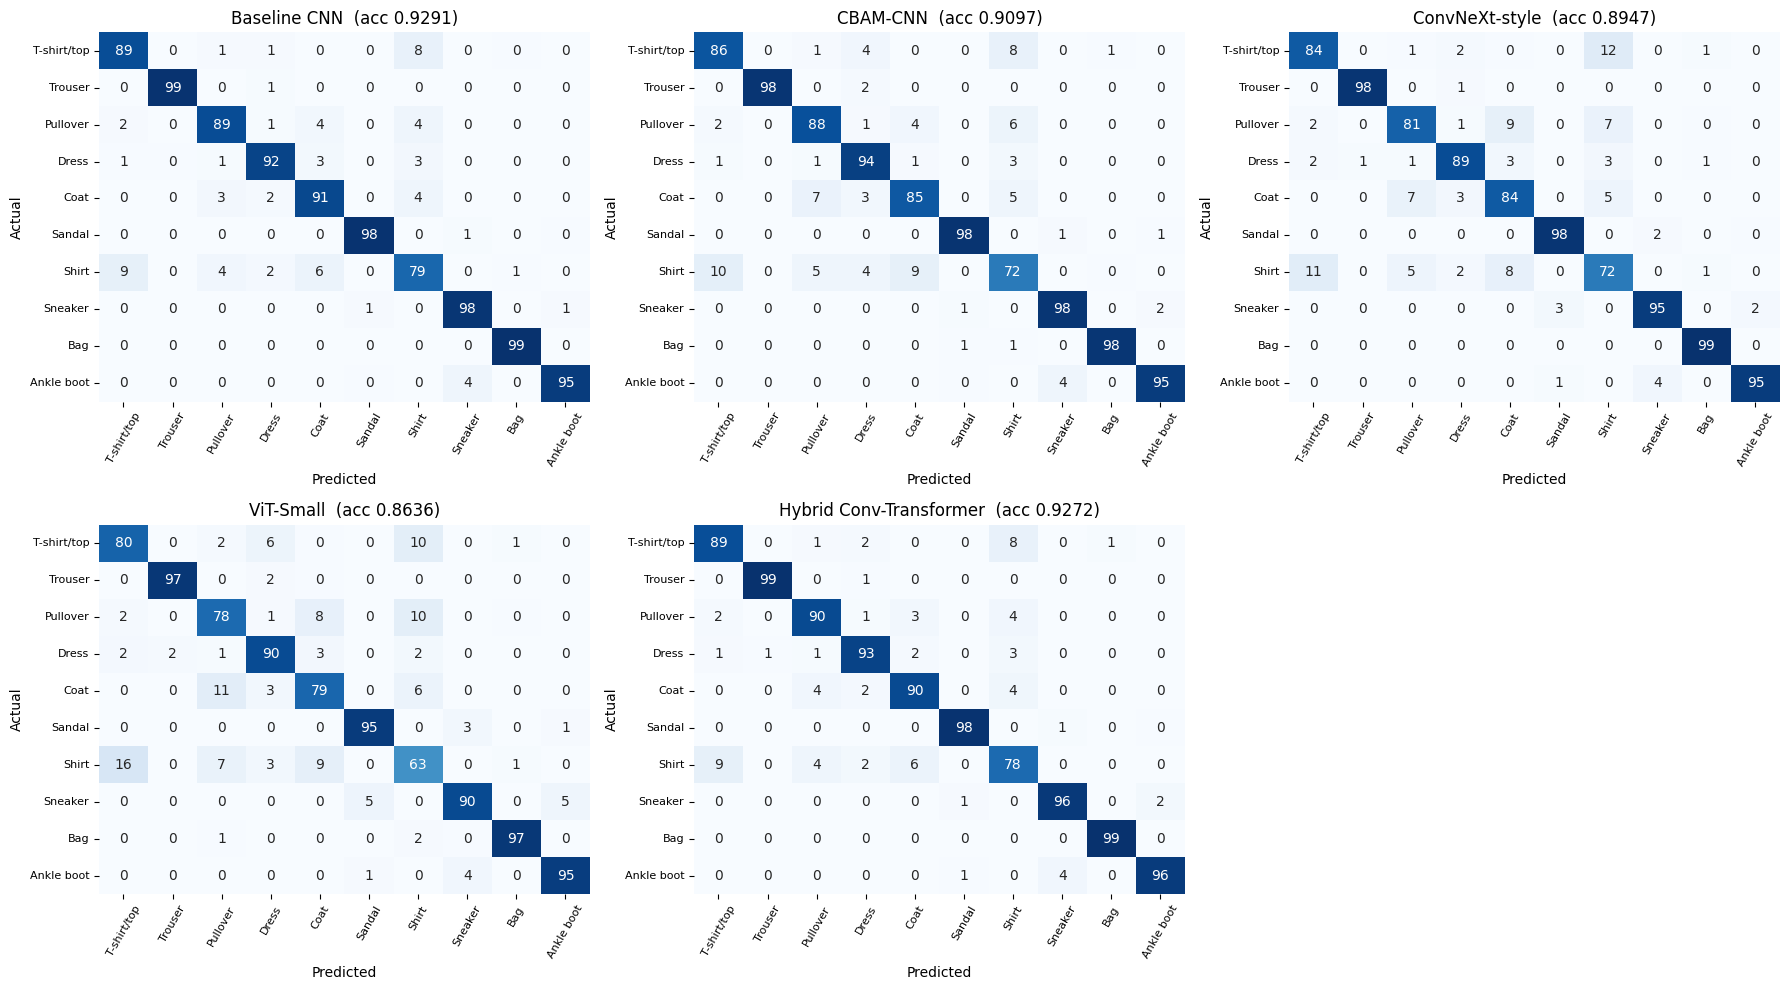

In [16]:
# Confusion matrices (row-normalised, % of each true class)
n = len(results)
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
for ax, (name, r) in zip(axes.ravel(), results.items()):
    cm_pct = r['cm'] / r['cm'].sum(axis=1, keepdims=True) * 100
    sns.heatmap(cm_pct, annot=True, fmt='.0f', cmap='Blues', cbar=False, ax=ax,
                xticklabels=class_names, yticklabels=class_names, vmin=0, vmax=100)
    ax.set_title(f"{name}  (acc {r['accuracy']:.4f})")
    ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
    ax.tick_params(axis='x', rotation=60, labelsize=8); ax.tick_params(axis='y', labelsize=8)
for ax in axes.ravel()[n:]:
    ax.axis('off')
plt.tight_layout(); plt.show()

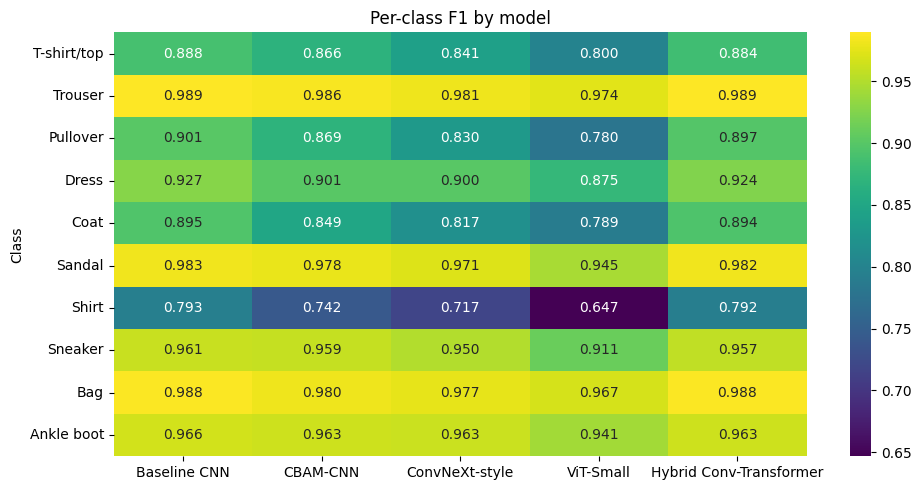

Hardest classes (mean F1 across models):
Class
Shirt       0.7381
Coat        0.8488
Pullover    0.8553


In [17]:
# Per-class F1 across models - where do the architectures actually differ?
f1_table = pd.DataFrame({n: r['per_class'].set_index('Class')['F1'] for n, r in results.items()})
plt.figure(figsize=(10, 5))
sns.heatmap(f1_table, annot=True, fmt='.3f', cmap='viridis')
plt.title('Per-class F1 by model')
plt.tight_layout(); plt.show()

hard = f1_table.mean(axis=1).sort_values().head(3)
print("Hardest classes (mean F1 across models):")
print(hard.round(4).to_string())

In [18]:
# Full per-class breakdown (precision / recall / F1 / specificity / AUC) for the best model
best_name = summary_df.loc[0, 'Model']
print(f"Per-class breakdown - {best_name}")
results[best_name]['per_class'].round(4)

Per-class breakdown - Baseline CNN


,Class,Precision,Recall,F1,Specificity,ROC-AUC
0,T-shirt/top,0.8880,0.888,0.8880,0.9876,0.9940
1,Trouser,0.9930,0.986,0.9895,0.9992,0.9998
2,Pullover,0.9084,0.893,0.9007,0.9900,0.9947
3,Dress,0.9304,0.923,0.9267,0.9923,0.9976
4,Coat,0.8801,0.910,0.8948,0.9862,0.9950
5,Sandal,0.9801,0.985,0.9825,0.9978,0.9998
6,Shirt,0.7984,0.788,0.7932,0.9779,0.9821
7,Sneaker,0.9466,0.975,0.9606,0.9939,0.9992
8,Bag,0.9851,0.991,0.9880,0.9983,0.9999
9,Ankle boot,0.9814,0.952,0.9665,0.9980,0.9994


## 11. Efficiency and Calibration

Accuracy alone hides cost and trustworthiness. **ECE** (expected calibration error) and **NLL** (test log-loss) measure whether predicted confidence matches actual correctness; lower is better. Latency is wall-clock `predict` time per 1,000 images on whatever hardware this runs on (includes framework overhead, so use it for relative comparison only).

In [19]:
def latency_ms_per_1000(model, reps=3):
    xb = x_test[:1000]
    model.predict(xb, batch_size=500, verbose=0)          # warm-up
    t0 = time.time()
    for _ in range(reps):
        model.predict(xb, batch_size=500, verbose=0)
    return (time.time() - t0) / reps * 1000 * (1000 / len(xb))


eff_df = pd.DataFrame([{
    'Model': n, 'Family': REGISTRY[n]['family'],
    'Params': m.count_params(),
    'Epochs Run': len(histories[n].history['loss']),
    'Train Time (s)': round(train_times[n], 1),
    'Latency (ms / 1000 imgs)': round(latency_ms_per_1000(m), 1),
    'Accuracy': round(results[n]['accuracy'], 4),
    'ECE': round(results[n]['ece'], 4),
    'NLL': round(results[n]['nll'], 4),
} for n, m in trained.items()]).sort_values('Accuracy', ascending=False).reset_index(drop=True)
eff_df['Acc per 100k params'] = (eff_df['Accuracy'] / (eff_df['Params'] / 1e5)).round(4)
eff_df

,Model,Family,Params,Epochs Run,Train Time (s),Latency (ms / 1000 imgs),Accuracy,ECE,NLL,Acc per 100k params
0,Baseline CNN,CNN,111370,30,212.0,95.7,0.9291,0.0102,0.2005,0.8342
1,Hybrid Conv-Transformer,CNN+Transformer,305194,30,763.1,129.9,0.9272,0.0147,0.2044,0.3038
2,CBAM-CNN,CNN,117295,17,243.0,105.6,0.9097,0.0077,0.2494,0.7756
3,ConvNeXt-style,Modern CNN,221146,30,810.2,165.4,0.8947,0.0111,0.2822,0.4046
4,ViT-Small,Transformer,205834,30,871.0,121.4,0.8636,0.0254,0.3762,0.4196


## 12. Statistical Significance (McNemar's exact test)

Two models can differ by 0.2% test accuracy purely by chance. McNemar's test looks only at the test images where the two models *disagree* in correctness and asks whether one wins those disagreements more often than a coin flip would. Cells below are p-values (pairwise, two-sided exact binomial). With 10 pairwise comparisons, use a Bonferroni-corrected threshold of 0.05 / 10 = 0.005.

This tests whether the two *trained models* differ on this test set. It does **not** capture training-seed variance; Section 13 does that.

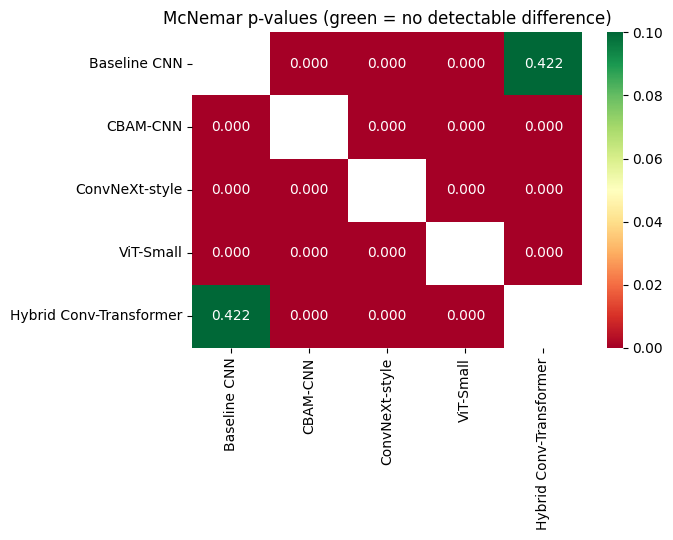

,Model A,Model B,Acc diff (A-B),"A right, B wrong","B right, A wrong",p-value,Significant (Bonferroni 0.005)
0,Baseline CNN,CBAM-CNN,0.0194,392,198,0.0000,True
1,Baseline CNN,ConvNeXt-style,0.0344,557,213,0.0000,True
2,Baseline CNN,ViT-Small,0.0655,868,213,0.0000,True
3,CBAM-CNN,ConvNeXt-style,0.0150,463,313,0.0000,True
4,CBAM-CNN,Hybrid Conv-Transformer,-0.0175,221,396,0.0000,True
5,CBAM-CNN,ViT-Small,0.0461,718,257,0.0000,True
6,ConvNeXt-style,ViT-Small,0.0311,636,325,0.0000,True
7,ConvNeXt-style,Hybrid Conv-Transformer,-0.0325,229,554,0.0000,True
8,ViT-Small,Hybrid Conv-Transformer,-0.0636,223,859,0.0000,True
9,Baseline CNN,Hybrid Conv-Transformer,0.0019,261,242,0.4222,False


In [20]:
def mcnemar_exact(y_true, pred_a, pred_b):
    a_ok, b_ok = pred_a == y_true, pred_b == y_true
    only_a = int(np.sum(a_ok & ~b_ok)); only_b = int(np.sum(~a_ok & b_ok))
    n_disc = only_a + only_b
    p = binomtest(min(only_a, only_b), n_disc, 0.5).pvalue if n_disc > 0 else 1.0
    return only_a, only_b, p


names = list(results)
pmat = pd.DataFrame(np.nan, index=names, columns=names)
rows = []
for a, b in itertools.combinations(names, 2):
    oa, ob, p = mcnemar_exact(y_test, results[a]['y_pred'], results[b]['y_pred'])
    pmat.loc[a, b] = pmat.loc[b, a] = p
    rows.append({'Model A': a, 'Model B': b,
                 'Acc diff (A-B)': round(results[a]['accuracy'] - results[b]['accuracy'], 4),
                 'A right, B wrong': oa, 'B right, A wrong': ob, 'p-value': round(p, 4),
                 'Significant (Bonferroni 0.005)': p < 0.005})
pairwise_df = pd.DataFrame(rows).sort_values('p-value').reset_index(drop=True)

plt.figure(figsize=(7, 5.5))
sns.heatmap(pmat.astype(float), annot=True, fmt='.3f', cmap='RdYlGn', vmin=0, vmax=0.1, mask=pmat.isna())
plt.title("McNemar p-values (green = no detectable difference)")
plt.tight_layout(); plt.show()
pairwise_df

## 13. Seed Variance Study (optional, slow)

One training run per model gives one draw from a noisy process. Set `RUN_SEED_STUDY = True` in the configuration cell to retrain each model `SEED_RUNS` times with different seeds and report mean +/- std of test accuracy. If the gap between two models is smaller than the seed-to-seed std, the ranking is not trustworthy.

In [21]:
if RUN_SEED_STUDY:
    seed_rows = []
    for name, cfg in REGISTRY.items():
        accs = [results[name]['accuracy']]                      # include the main run
        for s in range(1, SEED_RUNS):
            keras.utils.set_random_seed(SEED + s)
            m = cfg['builder'](name=f"seed{s}", **best_cfg[name])
            compile_and_train(m, EPOCHS, patience=6, verbose=0)
            accs.append(accuracy_score(y_test, m.predict(x_test, batch_size=512, verbose=0).argmax(1)))
            del m; keras.backend.clear_session()
        seed_rows.append({'Model': name, 'Runs': len(accs), 'Mean Acc': np.mean(accs),
                          'Std': np.std(accs, ddof=1), 'Min': np.min(accs), 'Max': np.max(accs)})
        print(f"{name}: {np.mean(accs):.4f} +/- {np.std(accs, ddof=1):.4f}")
    seed_df = pd.DataFrame(seed_rows).sort_values('Mean Acc', ascending=False).round(4).reset_index(drop=True)
    display(seed_df)
else:
    print("Seed study skipped (RUN_SEED_STUDY = False). Rankings above come from a single seed.")

Seed study skipped (RUN_SEED_STUDY = False). Rankings above come from a single seed.


## 14. What the ViT Attends To (Attention Rollout)

Attention rollout (Abnar & Zuidema, 2020) multiplies the head-averaged attention matrices across layers, with the residual connection modelled as an identity term, to estimate how much each input patch influences the final representation. Bright regions = patches the network relied on. This is an approximation, not a causal explanation.

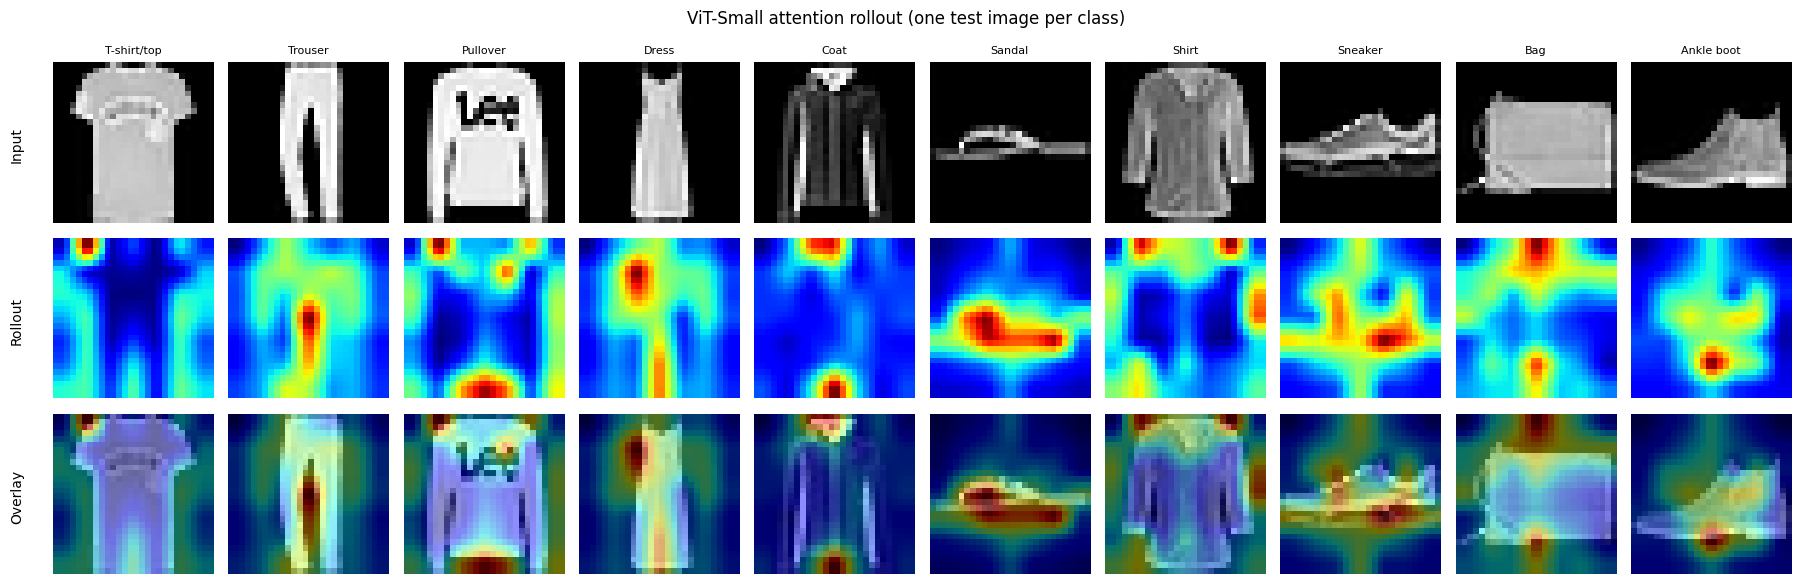

In [22]:
def vit_attention_rollout(vit, imgs):
    blocks = [l for l in vit.layers if isinstance(l, TransformerBlock)]
    x = vit.get_layer('patch_embed')(imgs)                    # (B, s, s, D)
    B, s, D = tf.shape(x)[0], x.shape[1], x.shape[-1]
    N = s * s
    x = vit.get_layer('pos_embed')(tf.reshape(x, (B, N, D)))
    rollout = tf.eye(N, batch_shape=[B])
    for blk in blocks:
        x, scores = blk(x, training=False, return_attention=True)       # scores: (B, heads, N, N)
        a = tf.reduce_mean(scores, axis=1) + tf.eye(N)
        a = a / tf.reduce_sum(a, axis=-1, keepdims=True)
        rollout = tf.matmul(a, rollout)
    imp = tf.reshape(tf.reduce_mean(rollout, axis=1), (B, s, s, 1))     # attention each patch receives
    imp = tf.image.resize(imp, (28, 28), method='bilinear')[..., 0].numpy()
    imp -= imp.min(axis=(1, 2), keepdims=True)
    return imp / (imp.max(axis=(1, 2), keepdims=True) + 1e-8)


idx = [int(np.where(y_test == c)[0][0]) for c in range(10)]
maps = vit_attention_rollout(trained['ViT-Small'], x_test[idx])

fig, axes = plt.subplots(3, 10, figsize=(18, 6))
for j, i in enumerate(idx):
    axes[0, j].imshow(x_test[i].squeeze(), cmap='gray'); axes[0, j].set_title(class_names[y_test[i]], fontsize=8)
    axes[1, j].imshow(maps[j], cmap='jet')
    axes[2, j].imshow(x_test[i].squeeze(), cmap='gray'); axes[2, j].imshow(maps[j], cmap='jet', alpha=0.45)
    for r in range(3):
        axes[r, j].axis('off')
axes[0, 0].text(-8, 14, 'Input', rotation=90, va='center'); axes[1, 0].text(-8, 14, 'Rollout', rotation=90, va='center')
axes[2, 0].text(-8, 14, 'Overlay', rotation=90, va='center')
plt.suptitle('ViT-Small attention rollout (one test image per class)')
plt.tight_layout(); plt.show()

## 15. Comparison with Published Results

The five reference rows are carried over unchanged from the earlier notebook. **Verify them before submission**: confirm the arXiv ID and each accuracy figure against the actual paper, because they were not independently re-checked here. Precision/Recall/F1/AUC are marked `Not reported` for those rows rather than invented. Published models were typically trained far longer and some use heavy augmentation or ImageNet pretraining, so this is context, not a like-for-like contest.

In [23]:
def ref_row(name, acc, params='Not reported', source=''):
    return {'Model': name, 'Accuracy': acc, 'Precision': 'Not reported', 'Recall': 'Not reported',
            'F1': 'Not reported', 'AUC': 'Not reported', 'Parameters': params, 'Source': source}

SRC = 'arXiv:1802.07589 (verify)'
sota_rows = [
    ref_row('VGG16', 0.935, '26,000,000', SRC),
    ref_row('GoogLeNet', 0.937, source=SRC),
    ref_row('MobileNet', 0.950, source=SRC),
    ref_row('DenseNet-BC', 0.954, '768,000', SRC),
    ref_row('WRN-28-10 + Random Erasing', 0.963, source=SRC),
]
for n, r in results.items():
    sota_rows.append({'Model': f'{n} (this work)', 'Accuracy': r['accuracy'],
                      'Precision': round(r['precision_macro'], 4), 'Recall': round(r['recall_macro'], 4),
                      'F1': round(r['f1_macro'], 4), 'AUC': round(r['roc_auc_macro'], 4),
                      'Parameters': f"{trained[n].count_params():,}", 'Source': 'This work'})
sota_df = pd.DataFrame(sota_rows).sort_values('Accuracy', ascending=False).reset_index(drop=True)
sota_df

,Model,Accuracy,Precision,Recall,F1,AUC,Parameters,Source
0,WRN-28-10 + Random Erasing,0.9630,Not reported,Not reported,Not reported,Not reported,Not reported,arXiv:1802.07589 (verify)
1,DenseNet-BC,0.9540,Not reported,Not reported,Not reported,Not reported,"768,000",arXiv:1802.07589 (verify)
2,MobileNet,0.9500,Not reported,Not reported,Not reported,Not reported,Not reported,arXiv:1802.07589 (verify)
3,GoogLeNet,0.9370,Not reported,Not reported,Not reported,Not reported,Not reported,arXiv:1802.07589 (verify)
4,VGG16,0.9350,Not reported,Not reported,Not reported,Not reported,"26,000,000",arXiv:1802.07589 (verify)
5,Baseline CNN (this work),0.9291,0.9292,0.9291,0.929,0.9962,"111,370",This work
6,Hybrid Conv-Transformer (this work),0.9272,0.9268,0.9272,0.9269,0.9961,"305,194",This work
7,CBAM-CNN (this work),0.9097,0.9093,0.9097,0.9092,0.9942,"117,295",This work
8,ConvNeXt-style (this work),0.8947,0.8949,0.8947,0.8946,0.9924,"221,146",This work
9,ViT-Small (this work),0.8636,0.8625,0.8636,0.8629,0.9885,"205,834",This work


## 16. Automatic Findings Summary

Generated from the numbers above so the written conclusion cannot drift from the results.

In [24]:
conv_fam = ['CNN', 'Modern CNN']
attn_fam = ['Transformer', 'CNN+Transformer']
best_conv = summary_df[summary_df['Family'].isin(conv_fam)].iloc[0]
best_attn = summary_df[summary_df['Family'].isin(attn_fam)].iloc[0]
vit_acc   = results['ViT-Small']['accuracy']
best_cnn_ref = summary_df[summary_df['Family'] == 'CNN'].iloc[0]

oa, ob, p = mcnemar_exact(y_test, results[best_conv['Model']]['y_pred'], results[best_attn['Model']]['y_pred'])

print(f"Best overall: {summary_df.loc[0, 'Model']} ({summary_df.loc[0, 'Accuracy']:.4f})")
print(f"Best convolution-based model:  {best_conv['Model']} ({best_conv['Accuracy']:.4f})")
print(f"Best attention/transformer-based model: {best_attn['Model']} ({best_attn['Accuracy']:.4f})")
print(f"Gap: {(best_attn['Accuracy'] - best_conv['Accuracy'])*100:+.2f} points | McNemar p = {p:.4f} "
      f"({'distinguishable' if p < 0.05 else 'NOT statistically distinguishable'} at 0.05)")
print()
print(f"Pure ViT vs best reference CNN ({best_cnn_ref['Model']}): "
      f"{(vit_acc - best_cnn_ref['Accuracy'])*100:+.2f} points")
if vit_acc < best_cnn_ref['Accuracy']:
    print("  -> The pure transformer did NOT beat the CNN. Expected: ViTs lack the locality/translation "
          "inductive bias of convolutions and need much more data (or pretraining) to overcome that.")
else:
    print("  -> The pure transformer matched or beat the CNN here. Check Section 13 before claiming this "
          "generalises; a single seed can flip a sub-0.5% gap.")
print()
hybrid_gain = results['Hybrid Conv-Transformer']['accuracy'] - vit_acc
print(f"Hybrid vs pure ViT: {hybrid_gain*100:+.2f} points "
      f"(conv stem effect; positive = convolutional priors helped the transformer)")
print(f"Calibration (ECE, lower is better): " +
      ", ".join(f"{n}={r['ece']:.4f}" for n, r in results.items()))

Best overall: Baseline CNN (0.9291)
Best convolution-based model:  Baseline CNN (0.9291)
Best attention/transformer-based model: Hybrid Conv-Transformer (0.9272)
Gap: -0.19 points | McNemar p = 0.4222 (NOT statistically distinguishable at 0.05)

Pure ViT vs best reference CNN (Baseline CNN): -6.55 points
  -> The pure transformer did NOT beat the CNN. Expected: ViTs lack the locality/translation inductive bias of convolutions and need much more data (or pretraining) to overcome that.

Hybrid vs pure ViT: +6.36 points (conv stem effect; positive = convolutional priors helped the transformer)
Calibration (ECE, lower is better): Baseline CNN=0.0102, CBAM-CNN=0.0077, ConvNeXt-style=0.0111, ViT-Small=0.0254, Hybrid Conv-Transformer=0.0147


## 17. Conclusion

_Fill in after running, using the generated numbers above. Suggested structure:_

- **Best model and margin:** name the winner, its accuracy, macro-F1 and AUC, and state whether the margin over the runner-up is statistically distinguishable (Section 12) and larger than seed variance (Section 13, if run).
- **CNN vs transformer finding:** report whether the pure ViT beat the CNN references, and by how much the hybrid and ConvNeXt-style models changed the picture. Explain with inductive bias (locality, weight sharing) and data scale (54k training images at 28x28).
- **Where models differ:** use the per-class F1 heatmap (Shirt / T-shirt / Pullover / Coat are the usual weak spots).
- **Cost trade-off:** parameters, training time, latency (Section 11). A model that gains 0.2% for 5x the compute is rarely a win.
- **Calibration:** which model's confidence can be trusted (ECE/NLL).
- **Limitations:** single dataset, grayscale 28x28, coarse short-run tuning, one seed unless Section 13 was run, published-reference rows not like-for-like.